In [13]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict


In [19]:
# Define State 
class BMIState(TypedDict):
    weight_kg: float  # in kilograms
    height_m: float  # in meters
    bmi: float  # Body Mass Index
    category: str  # BMI category (e.g., Underweight, Normal weight, Overweight, Obesity)

In [15]:
def calculate_bmi(state: BMIState) -> BMIState:
    """Calculate BMI from weight and height."""
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)

    state['bmi'] = round(bmi, 2)  # Round to 2 decimal places
    
    return state

In [20]:
def lable_bmi(state: BMIState) -> BMIState:
    """Label BMI category based on calculated BMI."""
    bmi = state['bmi']
    
    if bmi < 18.5:
        category = 'Underweight'
    elif 18.5 <= bmi < 25:
        category = 'Normal weight'
    elif 25 <= bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'
    
    state['category'] = category
    return state

In [ ]:
# Define the workflow graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('Calculate BMI', calculate_bmi)
graph.add_node('Label BMI', lable_bmi)

# add edges to your graph
graph.add_edge(START, 'Calculate BMI')  # start to calculate BMI
graph.add_edge('Calculate BMI', 'Label BMI')  # calculate BMI to label BMI
graph.add_edge('Label BMI', END)  # label BMI to end

# compile your graph
workflow = graph.compile()

# execute your graph
initial_state = {
    'weight_kg': 70,  # example weight in kg
    'height_m': 1.75  # example height in meters
}


final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86}


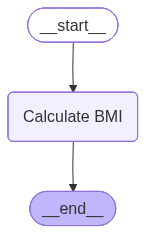

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())